# Entrega 2 – Análise Exploratória de Dados (EDA)

Tema 14 – Fake News e Informação Online

Este notebook realiza a análise exploratória completa do dataset FactCenter, cobrindo:

1. Carregamento dos artefatos gerados no pré-processamento
2. Estatísticas descritivas
3. Distribuição por rating, agência e tempo
4. Análise de categorias
5. Distribuição de tamanho dos textos
6. Correlação entre variáveis numéricas
7. Análise de variância explicada (PCA)
8. Visualização UMAP com anotações
9. Análise de similaridade/dissimilaridade entre classes
10. Impacto da normalização nas distâncias

## 1. Importações e carregamento dos artefatos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, normalize
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="muted")

ARTIFACTS_DIR = Path("../../artifacts")

df         = pd.read_parquet(ARTIFACTS_DIR / "df_clean.parquet")
embeddings = np.load(ARTIFACTS_DIR / "embeddings.npy")
X_pca      = np.load(ARTIFACTS_DIR / "X_pca.npy")
X_umap     = np.load(ARTIFACTS_DIR / "umap_2d.npy")

print(f"Dataset:    {df.shape}")
print(f"Embeddings: {embeddings.shape}")
print(f"X_pca:      {X_pca.shape}")
print(f"X_umap:     {X_umap.shape}")

Dataset:    (11539, 9)
Embeddings: (11539, 1024)
X_pca:      (11539, 424)
X_umap:     (11539, 2)


## 2. Engenharia de features auxiliares

Criamos atributos numéricos derivados dos textos para análises estatísticas e de correlação.

In [2]:
df["title_word_count"] = df["title_clean"].str.split().str.len()
df["title_char_count"] = df["title_clean"].str.len()
df["n_categories"]     = df["categories"].map(len)
df["year"]             = df["publication_date"].dt.year
df["month"]            = df["publication_date"].dt.month

# tamanho do texto a partir do content (título×2 já retirado)
# estimativa: content = titulo×2 + texto[:1800], isolamos o texto
title_doubled = df["title_clean"] + " " + df["title_clean"] + " "
df["text_preview_len"] = df["content"].str.len() - title_doubled.str.len()

df[["title_word_count", "title_char_count", "n_categories", "text_preview_len"]].describe().round(2)

,title_word_count,title_char_count,n_categories,text_preview_len
count,11539.00,11539.00,11539.00,11539.00
mean,12.95,76.06,0.67,399.95
std,2.74,15.40,0.47,3.63
min,4.00,29.00,0.00,58.00
25%,11.00,66.00,0.00,400.00
50%,13.00,75.00,1.00,400.00
75%,15.00,85.00,1.00,400.00
max,40.00,197.00,1.00,400.00


## 3. Estatísticas descritivas gerais

In [3]:
print(f"Total de registros:       {len(df)}")
print(f"Período coberto:          {df['publication_date'].min().date()} → {df['publication_date'].max().date()}")
print(f"Agências de fact-checking:{df['source_name'].nunique()}")
print(f"Categorias únicas:        {df['categories'].explode().nunique()}")
print(f"Classes de rating:        {df['rating_norm'].nunique()}")

Total de registros:       11539
Período coberto:          2013-07-01 → 2021-05-19
Agências de fact-checking:6
Categorias únicas:        26
Classes de rating:        4


## 4. Distribuição por rating normalizado

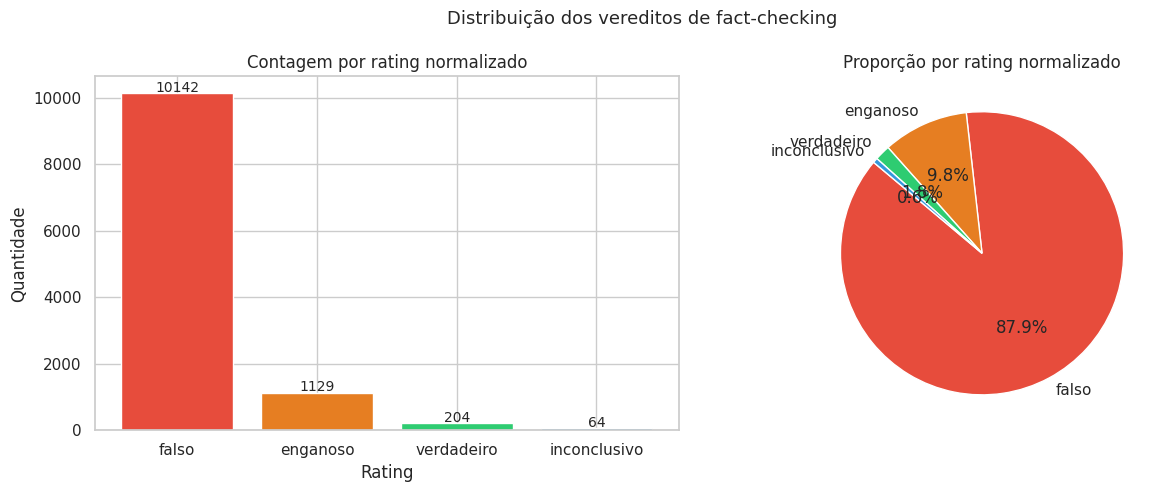


Desbalanceamento: a classe 'falso' domina o dataset.
Razão falso/verdadeiro: 49.7x


In [4]:
PALETTE = {
    "falso":        "#e74c3c",
    "enganoso":     "#e67e22",
    "verdadeiro":   "#2ecc71",
    "inconclusivo": "#3498db",
    "outros":       "#95a5a6",
    "sem_rating":   "#bdc3c7",
}

counts = df["rating_norm"].value_counts()
colors = [PALETTE.get(r, "#95a5a6") for r in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# barras
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, str(v), ha="center", fontsize=10)
axes[0].set_title("Contagem por rating normalizado")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Quantidade")

# pizza
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white"},
)
axes[1].set_title("Proporção por rating normalizado")

plt.suptitle("Distribuição dos vereditos de fact-checking", fontsize=13)
plt.tight_layout()
plt.show()

print("\nDesbalanceamento: a classe 'falso' domina o dataset.")
print(f"Razão falso/verdadeiro: {counts['falso'] / counts.get('verdadeiro', 1):.1f}x")

## 5. Distribuição por agência de fact-checking

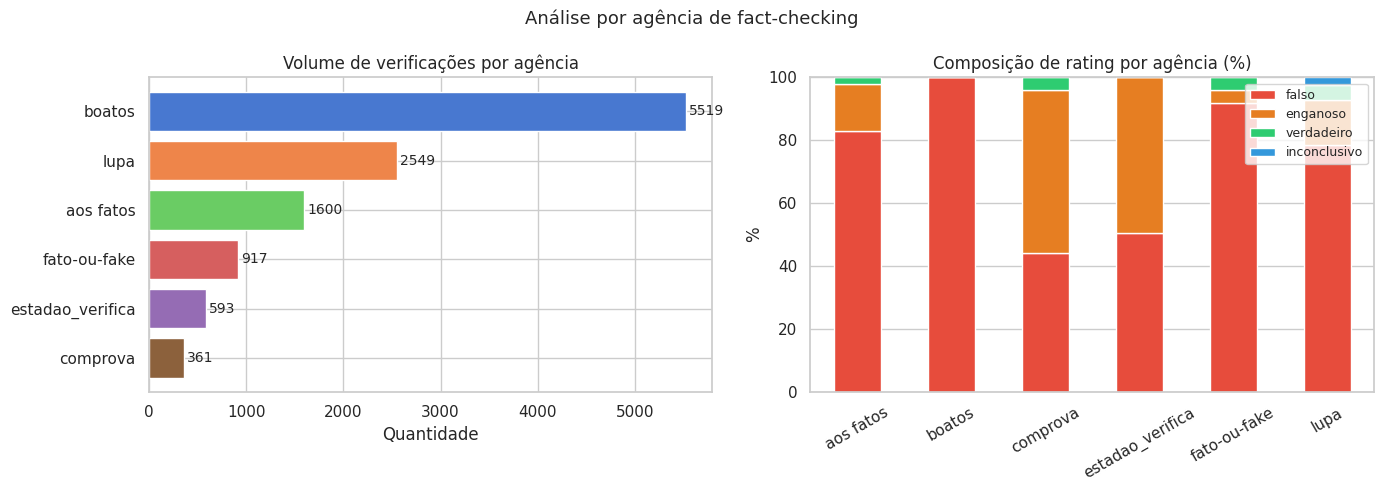

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# volume por agência
src_counts = df["source_name"].value_counts()
axes[0].barh(src_counts.index, src_counts.values, color=sns.color_palette("muted", len(src_counts)))
for i, v in enumerate(src_counts.values):
    axes[0].text(v + 30, i, str(v), va="center", fontsize=10)
axes[0].set_title("Volume de verificações por agência")
axes[0].set_xlabel("Quantidade")
axes[0].invert_yaxis()

# composição de rating por agência
rating_src = (
    df.groupby(["source_name", "rating_norm"])
    .size()
    .unstack(fill_value=0)
)
rating_src_pct = rating_src.div(rating_src.sum(axis=1), axis=0) * 100
rating_src_pct[[c for c in PALETTE if c in rating_src_pct.columns]].plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[PALETTE[c] for c in PALETTE if c in rating_src_pct.columns],
    edgecolor="white",
)
axes[1].set_title("Composição de rating por agência (%)")
axes[1].set_xlabel("")
axes[1].set_ylabel("%")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Análise por agência de fact-checking", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Evolução temporal das verificações

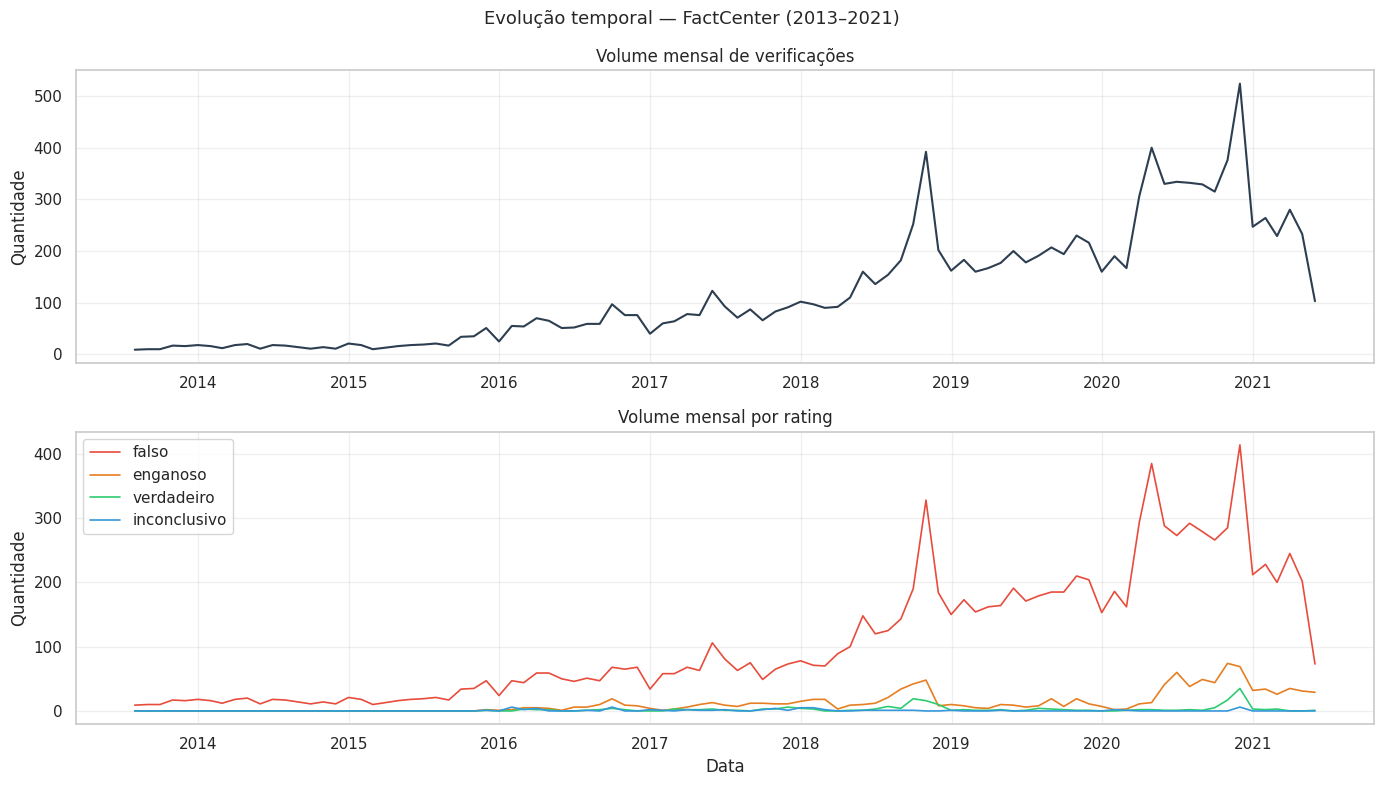

In [6]:
monthly = (
    df.groupby([pd.Grouper(key="publication_date", freq="ME"), "rating_norm"])
    .size()
    .unstack(fill_value=0)
)

dates = monthly.index.to_pydatetime()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# volume total
axes[0].plot(dates, monthly.sum(axis=1).values, color="#2c3e50", linewidth=1.5)
axes[0].set_title("Volume mensal de verificações")
axes[0].set_ylabel("Quantidade")
axes[0].grid(alpha=0.3)

# por rating
for rating, color in PALETTE.items():
    if rating in monthly.columns:
        axes[1].plot(dates, monthly[rating].values, label=rating, color=color, linewidth=1.2)
axes[1].set_title("Volume mensal por rating")
axes[1].set_ylabel("Quantidade")
axes[1].set_xlabel("Data")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Evolução temporal — FactCenter (2013–2021)", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Distribuição de tamanho dos títulos

Histogramas e boxplots por rating para identificar se o comprimento do título
varia sistematicamente entre classes.

/tmp/ipykernel_81488/3864579260.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=MAIN_RATINGS, patch_artist=True)


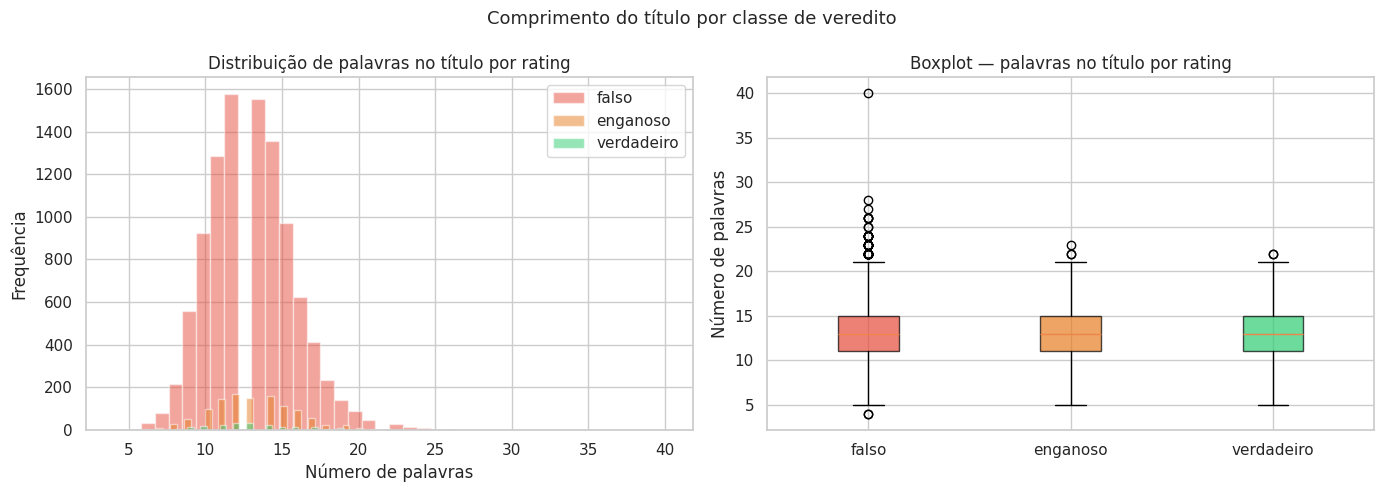

,count,mean,std,min,25%,50%,75%,max
rating_norm,,,,,,,,
enganoso,1129.0,13.07,2.71,5.0,11.0,13.0,15.0,23.0
falso,10142.0,12.94,2.74,4.0,11.0,13.0,15.0,40.0
verdadeiro,204.0,13.05,3.02,5.0,11.0,13.0,15.0,22.0


In [7]:
MAIN_RATINGS = ["falso", "enganoso", "verdadeiro"]
df_main = df[df["rating_norm"].isin(MAIN_RATINGS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogramas sobrepostos
for rating in MAIN_RATINGS:
    sub = df_main[df_main["rating_norm"] == rating]["title_word_count"]
    axes[0].hist(sub, bins=40, alpha=0.5, label=rating, color=PALETTE[rating])
axes[0].set_title("Distribuição de palavras no título por rating")
axes[0].set_xlabel("Número de palavras")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# boxplot
data_box = [df_main[df_main["rating_norm"] == r]["title_word_count"].values for r in MAIN_RATINGS]
bp = axes[1].boxplot(data_box, labels=MAIN_RATINGS, patch_artist=True)
for patch, rating in zip(bp["boxes"], MAIN_RATINGS):
    patch.set_facecolor(PALETTE[rating])
    patch.set_alpha(0.7)
axes[1].set_title("Boxplot — palavras no título por rating")
axes[1].set_ylabel("Número de palavras")

plt.suptitle("Comprimento do título por classe de veredito", fontsize=13)
plt.tight_layout()
plt.show()

df_main.groupby("rating_norm")["title_word_count"].describe().round(2)

## 8. Top categorias e co-ocorrências

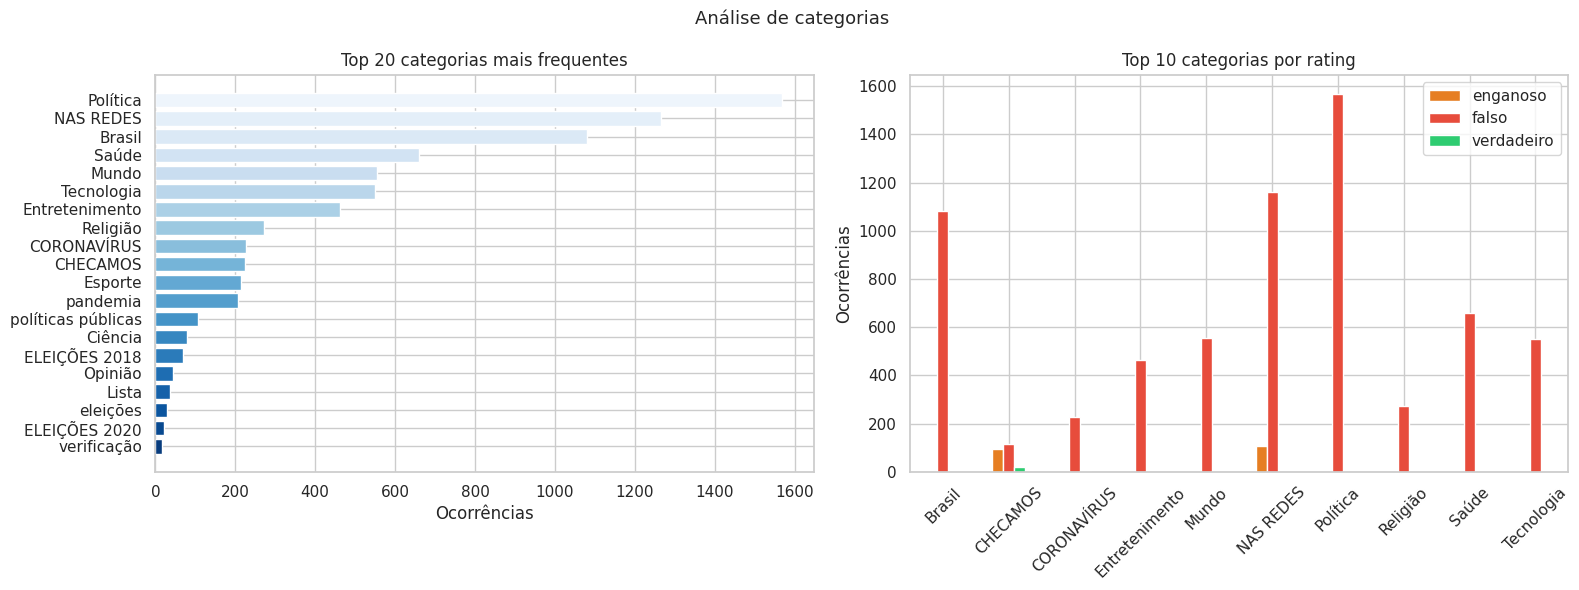

In [8]:
from collections import Counter

all_cats = [cat for cats in df["categories"] for cat in cats]
cat_counts = Counter(all_cats)
top_cats = pd.Series(cat_counts).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# top categorias geral
axes[0].barh(top_cats.index[::-1], top_cats.values[::-1], color=sns.color_palette("Blues_r", 20))
axes[0].set_title("Top 20 categorias mais frequentes")
axes[0].set_xlabel("Ocorrências")

# top categorias por rating
top10 = list(top_cats.index[:10])
cat_rating = []
for rating in MAIN_RATINGS:
    sub = df[df["rating_norm"] == rating]
    cats = [c for cats in sub["categories"] for c in cats if c in top10]
    cnt = Counter(cats)
    for cat, n in cnt.items():
        cat_rating.append({"rating": rating, "categoria": cat, "n": n})

cat_rating_df = pd.DataFrame(cat_rating)
cat_rating_pivot = cat_rating_df.pivot(index="categoria", columns="rating", values="n").fillna(0)
cat_rating_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=[PALETTE[r] for r in cat_rating_pivot.columns],
    edgecolor="white",
)
axes[1].set_title("Top 10 categorias por rating")
axes[1].set_xlabel("")
axes[1].set_ylabel("Ocorrências")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.suptitle("Análise de categorias", fontsize=13)
plt.tight_layout()
plt.show()

## 8.1 Pureza de categorias por rating

Para cada categoria temática, calculamos a proporção de cada classe de veredito.
Categorias com alta pureza (dominadas por uma única classe) são mais informativas
para a interpretação dos clusters na etapa 3.

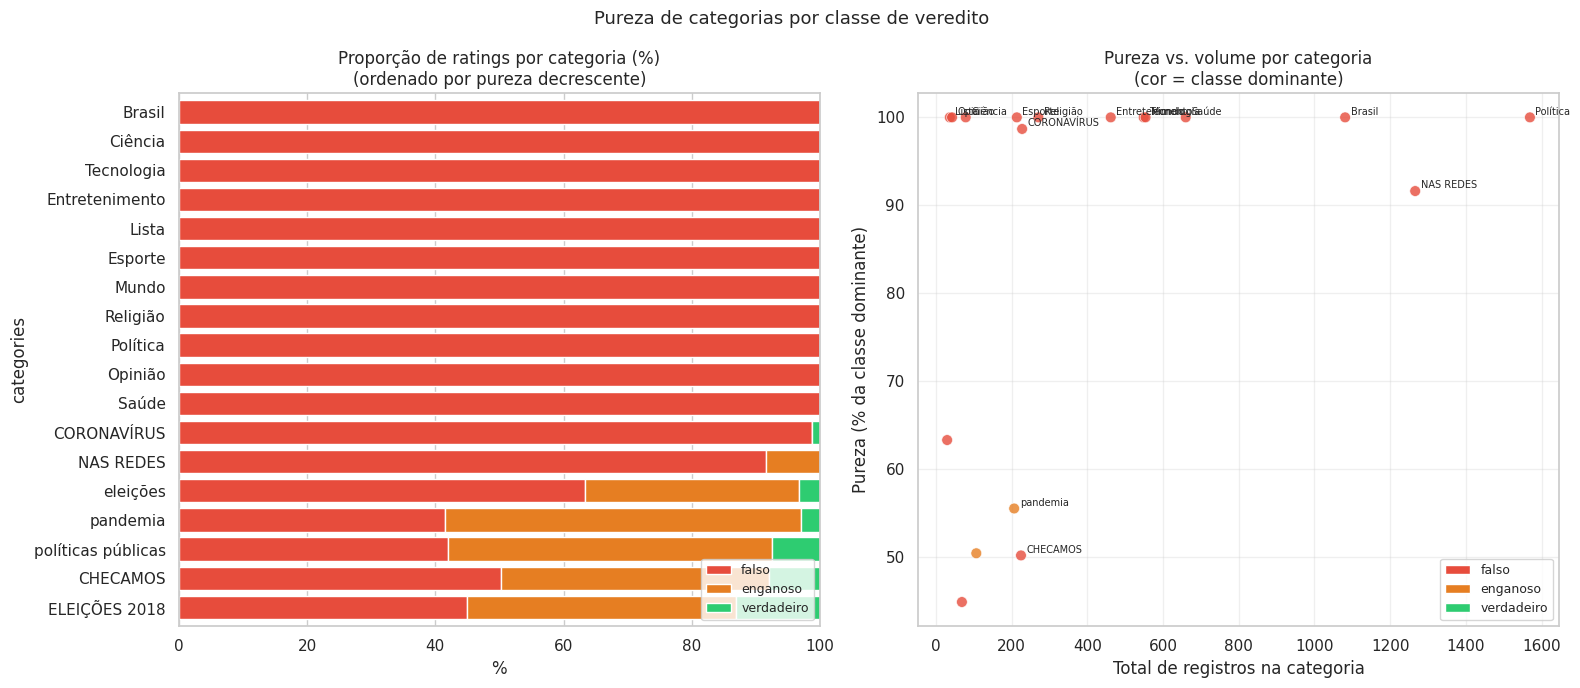


Top 10 categorias mais puras (mín. 30 registros):
rating_norm     falso  enganoso  verdadeiro dominante  pureza_%  total
categories                                                            
Brasil          100.0       0.0         0.0     falso     100.0   1081
Ciência         100.0       0.0         0.0     falso     100.0     79
Tecnologia      100.0       0.0         0.0     falso     100.0    549
Entretenimento  100.0       0.0         0.0     falso     100.0    462
Lista           100.0       0.0         0.0     falso     100.0     37
Esporte         100.0       0.0         0.0     falso     100.0    214
Mundo           100.0       0.0         0.0     falso     100.0    554
Religião        100.0       0.0         0.0     falso     100.0    271
Política        100.0       0.0         0.0     falso     100.0   1569
Opinião         100.0       0.0         0.0     falso     100.0     43

Categorias mais equilibradas (menor pureza):
rating_norm         falso  enganoso  verdadeiro dom

In [9]:
# expande uma linha por categoria (registros sem categoria são ignorados)
df_cats = df.explode("categories")
df_cats = df_cats[df_cats["categories"].str.strip().ne("") & df_cats["categories"].notna()]
df_cats = df_cats[df_cats["rating_norm"].isin(MAIN_RATINGS)]

# contagem e proporção por (categoria, rating)
cat_rating = (
    df_cats.groupby(["categories", "rating_norm"])
    .size()
    .unstack(fill_value=0)
)
cat_rating = cat_rating[[c for c in MAIN_RATINGS if c in cat_rating.columns]]

# só categorias com pelo menos 30 registros para evitar ruído
cat_rating = cat_rating[cat_rating.sum(axis=1) >= 30]
cat_pct = cat_rating.div(cat_rating.sum(axis=1), axis=0) * 100

# pureza = proporção da classe dominante
cat_pct["_dominante"] = cat_pct.idxmax(axis=1)
cat_pct["_pureza"]    = cat_pct[MAIN_RATINGS].max(axis=1)
cat_pct["_total"]     = cat_rating.sum(axis=1)

cat_pct_sorted = cat_pct.sort_values("_pureza", ascending=False)

# --- visualização ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# barras empilhadas — proporção por categoria
plot_data = cat_pct_sorted[[c for c in MAIN_RATINGS if c in cat_pct_sorted.columns]]
plot_data.plot(
    kind="barh",
    stacked=True,
    ax=axes[0],
    color=[PALETTE[c] for c in MAIN_RATINGS if c in plot_data.columns],
    edgecolor="white",
    width=0.8,
)
axes[0].set_title("Proporção de ratings por categoria (%)\n(ordenado por pureza decrescente)")
axes[0].set_xlabel("%")
axes[0].set_xlim(0, 100)
axes[0].legend(loc="lower right", fontsize=9)
axes[0].invert_yaxis()

# scatter pureza × total, colorido pela classe dominante
colors_dom = [PALETTE.get(d, "#95a5a6") for d in cat_pct_sorted["_dominante"]]
sc = axes[1].scatter(
    cat_pct_sorted["_total"],
    cat_pct_sorted["_pureza"],
    c=colors_dom,
    s=60,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.5,
)
for cat, row in cat_pct_sorted.iterrows():
    if row["_pureza"] > 90 or row["_total"] > 200:
        axes[1].annotate(
            cat,
            (row["_total"], row["_pureza"]),
            fontsize=7,
            xytext=(4, 2),
            textcoords="offset points",
        )
axes[1].set_xlabel("Total de registros na categoria")
axes[1].set_ylabel("Pureza (% da classe dominante)")
axes[1].set_title("Pureza vs. volume por categoria\n(cor = classe dominante)")
axes[1].grid(alpha=0.3)
# legenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[r], label=r) for r in MAIN_RATINGS]
axes[1].legend(handles=legend_elements, fontsize=9)

plt.suptitle("Pureza de categorias por classe de veredito", fontsize=13)
plt.tight_layout()
plt.show()

# tabela resumo
display_cols = MAIN_RATINGS + ["_dominante", "_pureza", "_total"]
print("\nTop 10 categorias mais puras (mín. 30 registros):")
print(cat_pct_sorted[display_cols].head(10).rename(columns={"_dominante": "dominante", "_pureza": "pureza_%", "_total": "total"}).round(1).to_string())

print("\nCategorias mais equilibradas (menor pureza):")
print(cat_pct_sorted[display_cols].tail(10).rename(columns={"_dominante": "dominante", "_pureza": "pureza_%", "_total": "total"}).round(1).to_string())

## 9. Correlação entre variáveis numéricas

Verificamos se há redundância entre os atributos numéricos derivados.

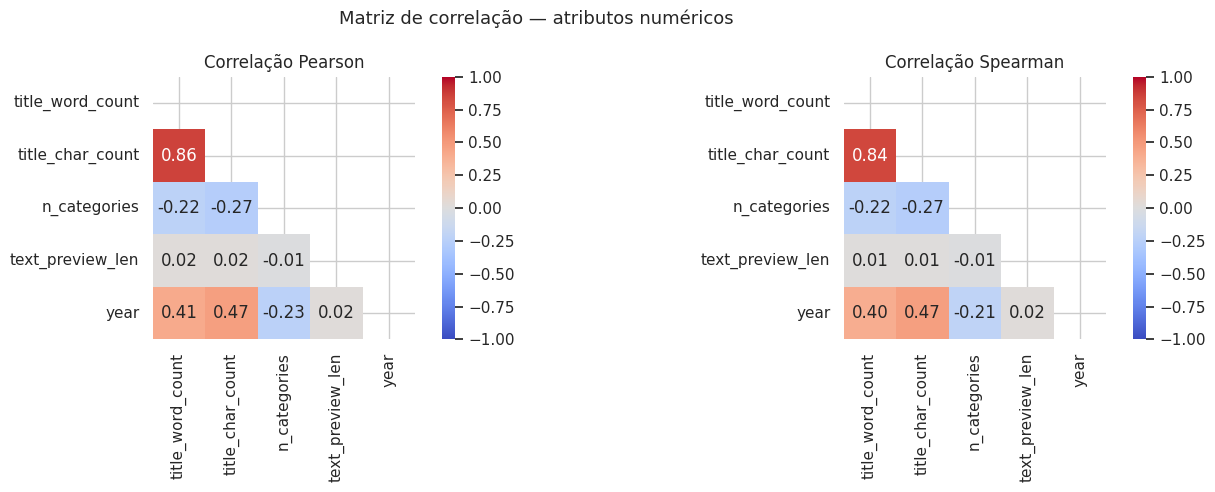


Atributos com correlação > 0.8 (Pearson) são candidatos à remoção por redundância:
  title_word_count × title_char_count: 0.86


In [10]:
num_cols = ["title_word_count", "title_char_count", "n_categories", "text_preview_len", "year"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, method in zip(axes, ["pearson", "spearman"]):
    corr = df[num_cols].corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        ax=ax, square=True,
    )
    ax.set_title(f"Correlação {method.capitalize()}")

plt.suptitle("Matriz de correlação — atributos numéricos", fontsize=13)
plt.tight_layout()
plt.show()

print("\nAtributos com correlação > 0.8 (Pearson) são candidatos à remoção por redundância:")
corr_p = df[num_cols].corr(method="pearson")
high = [(a, b, round(corr_p.loc[a,b], 2))
        for i, a in enumerate(num_cols)
        for j, b in enumerate(num_cols)
        if i < j and abs(corr_p.loc[a, b]) > 0.8]
for a, b, v in high:
    print(f"  {a} × {b}: {v}")
if not high:
    print("  Nenhum par com correlação > 0.8.")

## 10. Análise de variância explicada — PCA sobre embeddings

Mostramos quantas dimensões concentram a maior parte da informação dos embeddings.

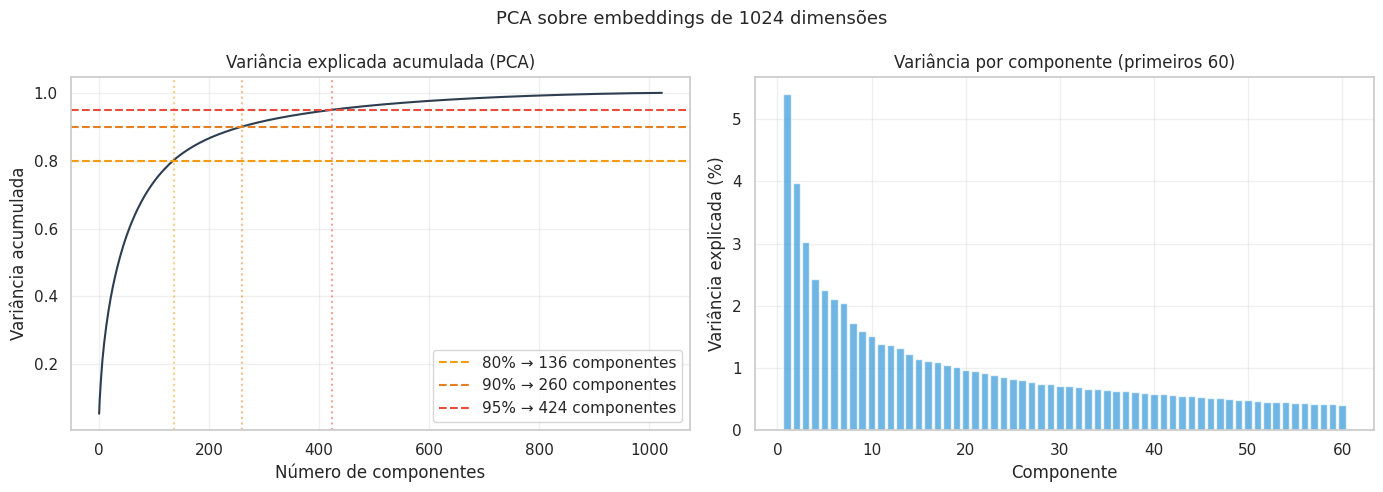

  80% da variância retida com 136 componentes (13.3% das dimensões originais)
  90% da variância retida com 260 componentes (25.4% das dimensões originais)
  95% da variância retida com 424 componentes (41.4% das dimensões originais)


In [11]:
pca_full = PCA(random_state=SEED)
pca_full.fit(embeddings)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

thresholds = {0.80: None, 0.90: None, 0.95: None}
for t in thresholds:
    thresholds[t] = int(np.searchsorted(cumvar, t)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# variância acumulada
axes[0].plot(cumvar, linewidth=1.5, color="#2c3e50")
colors_t = ["#f39c12", "#e67e22", "#e74c3c"]
for (t, n), c in zip(thresholds.items(), colors_t):
    axes[0].axhline(t, linestyle="--", color=c, label=f"{int(t*100)}% → {n} componentes")
    axes[0].axvline(n, linestyle=":", color=c, alpha=0.5)
axes[0].set_xlabel("Número de componentes")
axes[0].set_ylabel("Variância acumulada")
axes[0].set_title("Variância explicada acumulada (PCA)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# variância por componente (primeiros 60)
n_show = 60
axes[1].bar(
    range(1, n_show + 1),
    pca_full.explained_variance_ratio_[:n_show] * 100,
    color="#3498db", alpha=0.7,
)
axes[1].set_xlabel("Componente")
axes[1].set_ylabel("Variância explicada (%)")
axes[1].set_title(f"Variância por componente (primeiros {n_show})")
axes[1].grid(alpha=0.3)

plt.suptitle("PCA sobre embeddings de 1024 dimensões", fontsize=13)
plt.tight_layout()
plt.show()

for t, n in thresholds.items():
    print(f"  {int(t*100)}% da variância retida com {n} componentes ({n/embeddings.shape[1]*100:.1f}% das dimensões originais)")

## 11. Projeção UMAP — visualização 2D dos documentos

A projeção UMAP preserva a estrutura local do espaço de embeddings.
Clusters visualmente separados indicam que os documentos formam grupos semânticos coesos.

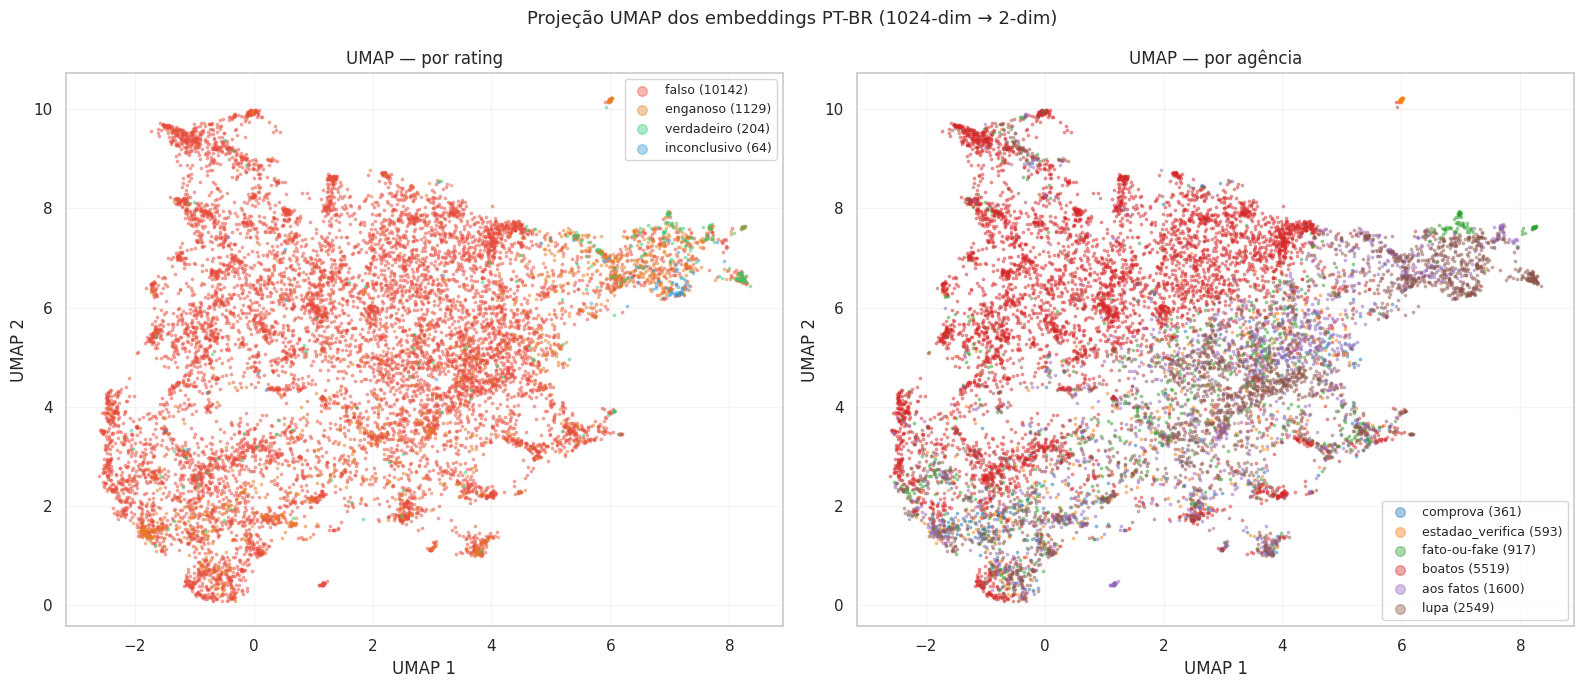

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# por rating
for label, color in PALETTE.items():
    mask = df["rating_norm"].values == label
    if mask.sum() == 0:
        continue
    axes[0].scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        s=3, alpha=0.4, color=color, label=f"{label} ({mask.sum()})", rasterized=True,
    )
axes[0].set_title("UMAP — por rating")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend(markerscale=4, fontsize=9)
axes[0].grid(alpha=0.2)

# por agência
sources = df["source_name"].unique()
palette_src = dict(zip(sources, sns.color_palette("tab10", len(sources))))
for src, color in palette_src.items():
    mask = df["source_name"].values == src
    axes[1].scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        s=3, alpha=0.4, color=color, label=f"{src} ({mask.sum()})", rasterized=True,
    )
axes[1].set_title("UMAP — por agência")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend(markerscale=4, fontsize=9)
axes[1].grid(alpha=0.2)

plt.suptitle("Projeção UMAP dos embeddings PT-BR (1024-dim → 2-dim)", fontsize=13)
plt.tight_layout()
plt.show()

## 12. UMAP por ano de publicação

Verificamos se há deriva temporal no espaço semântico — por exemplo, se notícias falsas
sobre pandemia (2020–2021) ocupam regiões distintas das notícias mais antigas.

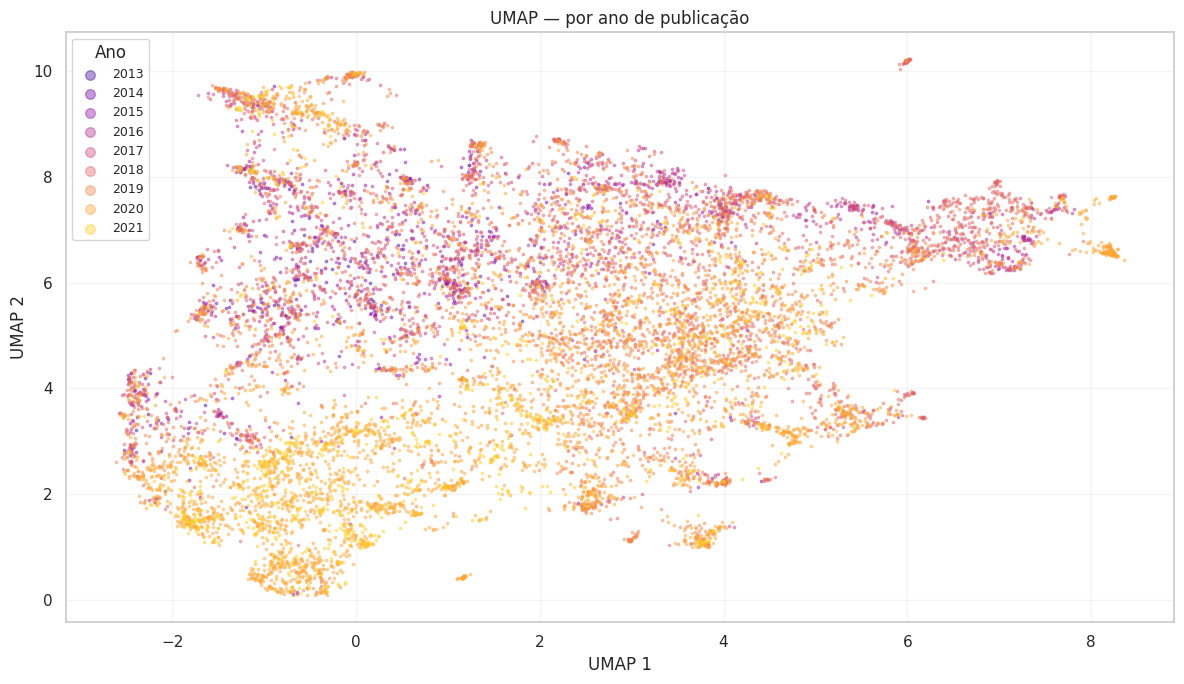

In [13]:
years = sorted(df["year"].dropna().unique().astype(int))
palette_year = dict(zip(years, sns.color_palette("plasma", len(years))))

fig, ax = plt.subplots(figsize=(12, 7))
for year, color in palette_year.items():
    mask = df["year"].values == year
    ax.scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        s=3, alpha=0.4, color=color, label=str(year), rasterized=True,
    )
ax.set_title("UMAP — por ano de publicação")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(markerscale=4, title="Ano", fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 13. Análise de similaridade e dissimilaridade entre classes

Calculamos distâncias cosseno e euclidianas médias **dentro** e **entre** classes.
Um bom espaço de representação mostra:
- distância **intra-classe** < distância **inter-classe**

Usamos amostras de até 500 documentos por classe para viabilidade computacional.

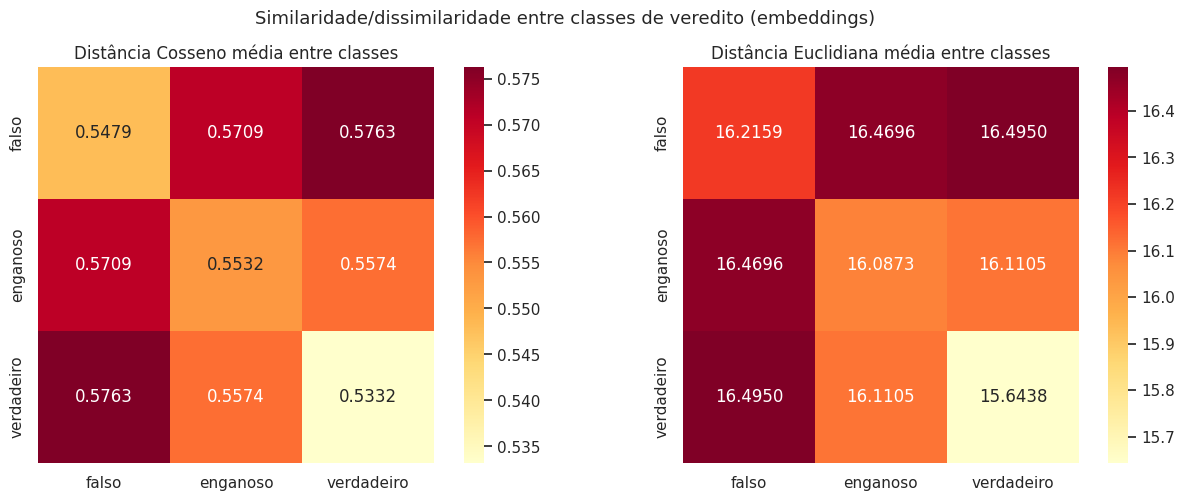


Distâncias cosseno:
             falso  enganoso  verdadeiro
falso       0.5479    0.5709      0.5763
enganoso    0.5709    0.5532      0.5574
verdadeiro  0.5763    0.5574      0.5332

Distâncias euclidianas:
              falso  enganoso  verdadeiro
falso       16.2159   16.4696     16.4950
enganoso    16.4696   16.0873     16.1105
verdadeiro  16.4950   16.1105     15.6438


In [14]:
samples = {}
for cls in MAIN_RATINGS:
    idx = np.where(df["rating_norm"].values == cls)[0]
    samples[cls] = np.random.choice(idx, size=min(500, len(idx)), replace=False)

def build_dist_matrix(emb, samples, dist_fn):
    classes = list(samples.keys())
    mat = pd.DataFrame(index=classes, columns=classes, dtype=float)
    for a in classes:
        for b in classes:
            mat.loc[a, b] = dist_fn(emb[samples[a]], emb[samples[b]]).mean()
    return mat.round(4)

cosine_mat   = build_dist_matrix(embeddings, samples, cosine_distances)
euclidean_mat = build_dist_matrix(embeddings, samples, euclidean_distances)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title in zip(axes,
                           [cosine_mat, euclidean_mat],
                           ["Distância Cosseno", "Distância Euclidiana"]):
    sns.heatmap(
        mat.astype(float), annot=True, fmt=".4f",
        cmap="YlOrRd", ax=ax, square=True,
    )
    ax.set_title(f"{title} média entre classes")

plt.suptitle("Similaridade/dissimilaridade entre classes de veredito (embeddings)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nDistâncias cosseno:")
print(cosine_mat)
print("\nDistâncias euclidianas:")
print(euclidean_mat)

## 14. Impacto da normalização nas distâncias

Comparamos as distâncias entre classes com e sem normalização dos embeddings.

- **Sem normalização:** magnitude do vetor varia com o conteúdo — pode favorecer documentos mais longos
- **L2 (normalização de norma):** todos os vetores projetados na hiperesfera unitária — distância euclidiana equivale a distância cosseno
- **StandardScaler:** centraliza e escala por dimensão — útil para K-Means, que é sensível a escala

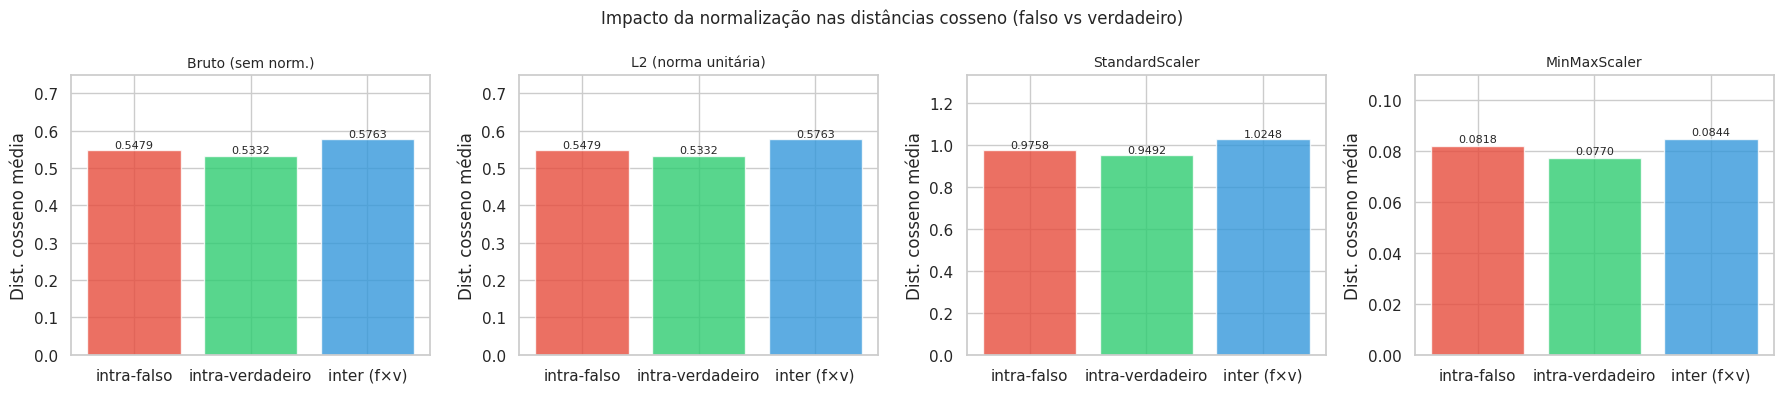

Interpretação: a normalização ideal mantém dist. intra-classe < dist. inter-classe,
maximizando a separabilidade dos grupos no espaço de representação.


In [15]:
# amostra compacta para comparação rápida
idx_sample = np.concatenate(list(samples.values()))
labels_sample = np.concatenate([[cls] * len(samples[cls]) for cls in samples])
emb_sample = embeddings[idx_sample]

transformations = {
    "Bruto (sem norm.)": emb_sample,
    "L2 (norma unitária)": normalize(emb_sample, norm="l2"),
    "StandardScaler": StandardScaler().fit_transform(emb_sample),
    "MinMaxScaler": MinMaxScaler().fit_transform(emb_sample),
}

fig, axes = plt.subplots(1, len(transformations), figsize=(18, 4))

for ax, (name, X) in zip(axes, transformations.items()):
    # distância cosseno inter-classe média (falso vs verdadeiro)
    mask_f = labels_sample == "falso"
    mask_v = labels_sample == "verdadeiro"
    d_inter = cosine_distances(X[mask_f], X[mask_v]).mean()
    d_intra_f = cosine_distances(X[mask_f], X[mask_f]).mean()
    d_intra_v = cosine_distances(X[mask_v], X[mask_v]).mean()

    bars = ax.bar(
        ["intra-falso", "intra-verdadeiro", "inter (f×v)"],
        [d_intra_f, d_intra_v, d_inter],
        color=["#e74c3c", "#2ecc71", "#3498db"],
        alpha=0.8,
    )
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("Dist. cosseno média")
    ax.set_ylim(0, max(d_intra_f, d_intra_v, d_inter) * 1.3)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=8,
        )

plt.suptitle(
    "Impacto da normalização nas distâncias cosseno (falso vs verdadeiro)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

print("Interpretação: a normalização ideal mantém dist. intra-classe < dist. inter-classe,")
print("maximizando a separabilidade dos grupos no espaço de representação.")

## 15. Exemplos representativos por cluster UMAP

Para cada região do espaço UMAP (quadrante), extraímos os títulos mais próximos
do centróide para dar interpretabilidade aos agrupamentos visuais.

In [16]:
from sklearn.metrics import pairwise_distances_argmin

# 6 centróides distribuídos no espaço UMAP por rating
for rating in MAIN_RATINGS:
    mask = df["rating_norm"].values == rating
    umap_sub = X_umap[mask]
    centroid = umap_sub.mean(axis=0, keepdims=True)
    closest_local = np.argmin(np.linalg.norm(umap_sub - centroid, axis=1))
    closest_global = np.where(mask)[0][closest_local]

    print(f"\n--- {rating.upper()} — documento mais central ---")
    print(f"  Título: {df['title'].iloc[closest_global]}")
    print(f"  Fonte:  {df['source_name'].iloc[closest_global]}")
    print(f"  Data:   {df['publication_date'].iloc[closest_global].date()}")


--- FALSO — documento mais central ---
  Título: Promotor manda prender menina de 12 anos que atirou em criminoso que invadiu sítio em Alta Floresta (MT) #boato
  Fonte:  boatos
  Data:   2019-10-03

--- ENGANOSO — documento mais central ---
  Título: Homem que anuncia a demissão de 60% de seus funcionários não é dono do Carrefour e Atacadão
  Fonte:  estadao_verifica
  Data:   2021-01-28

--- VERDADEIRO — documento mais central ---
  Título: Mudanças na lei eleitoral não valerão para 2020 se Bolsonaro aguardar até o fim do prazo para vetos
  Fonte:  comprova
  Data:   2019-09-19


## 16. Resumo da EDA

### Padrões observados

| Aspecto | Observação |
|---|---|
| **Desbalanceamento** | Classe `falso` domina (~87% dos registros); `verdadeiro` é minoria (~2%) |
| **Agências** | Boatos e Lupa dominam o volume; composição de rating varia por agência |
| **Temporal** | Pico de verificações em 2020 (pandemia COVID-19 visível) |
| **Categorias** | Saúde, Política e Pandemia são as mais frequentes |
| **Títulos** | Comprimento médio similar entre classes — discriminação não é trivial por tamanho |
| **PCA** | Alta dimensionalidade dos embeddings (1024-dim) requer ~420 componentes para 95% da variância |
| **UMAP** | Estrutura de clusters visível — agências produzem regiões distintas no espaço semântico |
| **Similaridade** | Distâncias intra-classe < inter-classe confirma separabilidade semântica |
| **Normalização** | L2 mantém melhor separabilidade cosseno; StandardScaler adequado para K-Means |